In [2]:
# Import core libraries and align the working directory with the repo root.
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

# Resolve project root so `src` is importable in notebooks.
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
os.chdir(project_root)

from src.tune import load_from_csv
from src.metrics import evaluate_model_performance

tabular_path = project_root / "data/transform/online_retail_daily_product_tabular.csv"
X_train, y_train, X_test, y_test, avg_price_arr = load_from_csv(str(tabular_path))

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)


/home/mwildanm/fmcg-dynamic-pricing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tabular CSV: /home/mwildanm/fmcg-dynamic-pricing/data/transform/online_retail_daily_product_tabular.csv
Global max date: 2011-12-09 00:00:00, cutoff: 2011-11-09 00:00:00
Train: (3349316, 26), Test: (141720, 26)
Zero-demand: train=85.2%, test=75.0%


In [3]:
# Stage 1: classify demand presence to address zero inflation early.
y_train_zero = (y_train > 0).astype(int)
count_zero = int((y_train_zero == 0).sum())
count_one = int((y_train_zero == 1).sum())
imbalance_ratio = count_zero / count_one if count_one > 0 else 1.0

clf = xgb.XGBClassifier(scale_pos_weight=imbalance_ratio)
clf.fit(X_train, y_train_zero)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [4]:
# Stage 2: regress demand magnitude only on non-zero samples.
nonzero_mask = y_train > 0
X_train_nonzero = X_train.loc[nonzero_mask]
y_train_nonzero = y_train.loc[nonzero_mask]

X_train_nonzero = X_train_nonzero.astype(np.float32)

reg = xgb.XGBRegressor()
reg.fit(X_train_nonzero, y_train_nonzero)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [5]:
# Combine classification thresholding with regression output for final forecast.
proba_nonzero = clf.predict_proba(X_test)[:, 1]
BUSINESS_THRESHOLD = 0.30
zero_pred_adjusted = (proba_nonzero >= BUSINESS_THRESHOLD).astype(int)

qty_pred = reg.predict(X_test)
final_pred = zero_pred_adjusted * qty_pred


In [6]:
# Evaluate using the centralized metric suite for statistical and business alignment.
metrics = evaluate_model_performance(
    y_true=y_test.values if hasattr(y_test, "values") else y_test,
    y_pred=final_pred,
    unit_prices=avg_price_arr,
    gross_margin=0.20,
    cogs=0.80,
    holding_daily=0.20 / 365,
)

metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["value"])
metrics_df


,value
MAE,8.785543
RMSE,218.054359
WAPE,1.502962
SMAPE_pct,143.772826
Global_Bias_pct,67.531403
F1_Zero,0.680300
MAE_NonZero,24.052588
CLS,147102.185619
IHC,828.173247
Total_Cost,147930.358866


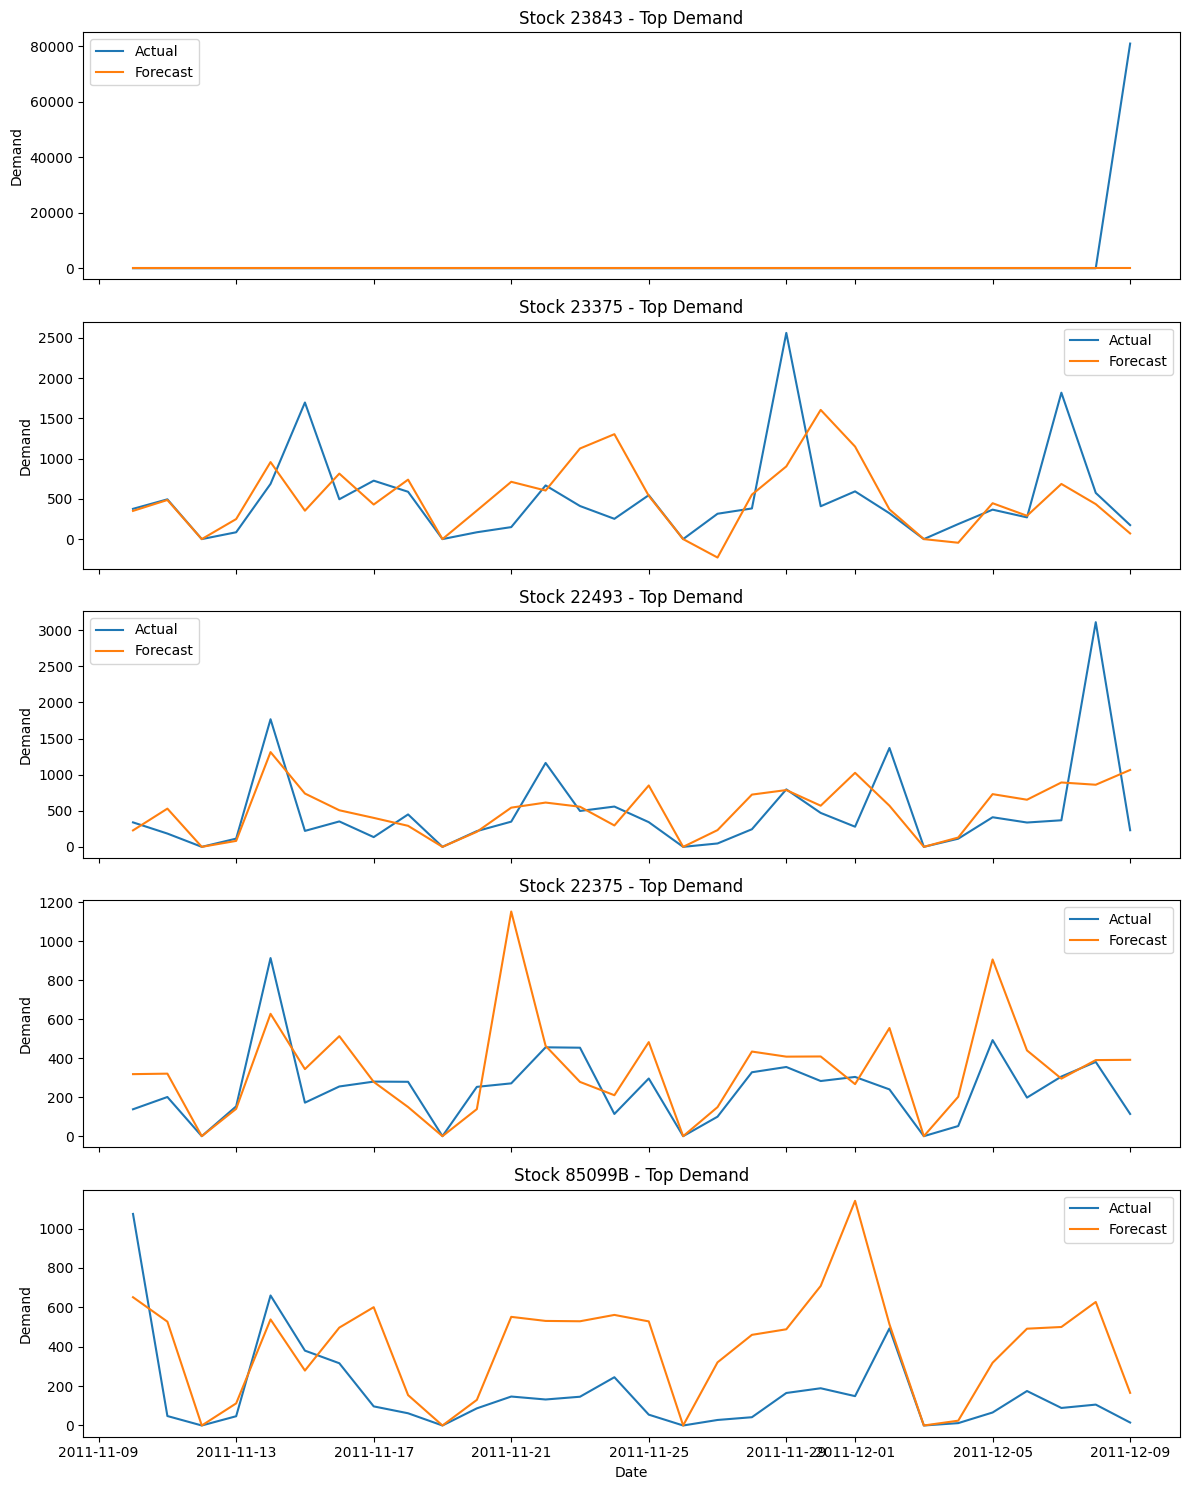

In [7]:
# Visualize forecasts for highest-demand products without loading full data into memory.
import matplotlib.pyplot as plt

use_cols = ["stock_code", "date", "demand_qty"]
max_date = None
for chunk in pd.read_csv(tabular_path, usecols=use_cols, chunksize=200_000, low_memory=False):
    chunk["date"] = pd.to_datetime(chunk["date"])
    chunk_max = chunk["date"].max()
    max_date = chunk_max if max_date is None else max(max_date, chunk_max)

cutoff = max_date - pd.Timedelta(days=30)

test_chunks = []
for chunk in pd.read_csv(tabular_path, usecols=use_cols, chunksize=200_000, low_memory=False):
    chunk["date"] = pd.to_datetime(chunk["date"])
    test_chunk = chunk[chunk["date"] > cutoff]
    if not test_chunk.empty:
        test_chunks.append(test_chunk)

df_test = pd.concat(test_chunks, ignore_index=True)
df_test = df_test.sort_values(["stock_code", "date"]).reset_index(drop=True)

if len(df_test) != len(y_test):
    raise ValueError("Mismatch between test rows and predictions.")

df_test["y_true"] = y_test.values
df_test["y_pred"] = final_pred

top_k = 5
top_products = (
    df_test.groupby("stock_code")["y_true"]
    .sum()
    .sort_values(ascending=False)
    .head(top_k)
    .index
)

fig, axes = plt.subplots(top_k, 1, figsize=(12, 3 * top_k), sharex=True)
if top_k == 1:
    axes = [axes]

for ax, stock_code in zip(axes, top_products):
    subset = df_test[df_test["stock_code"] == stock_code]
    ax.plot(subset["date"], subset["y_true"], label="Actual", linewidth=1.5)
    ax.plot(subset["date"], subset["y_pred"], label="Forecast", linewidth=1.5)
    ax.set_title(f"Stock {stock_code} - Top Demand")
    ax.set_ylabel("Demand")
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


In [8]:
# Ensure optional boosting libraries are available before training model zoo.
import importlib
import subprocess
import sys

missing = []
for pkg in ["lightgbm", "catboost"]:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All optional boosting dependencies already installed.")


All optional boosting dependencies already installed.


In [9]:
# Import model zoo dependencies after ensuring installation.
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import precision_score, recall_score, roc_curve, auc
from sklearn.metrics import mean_absolute_error, mean_squared_error
import gc


In [10]:
# Train and evaluate all classifier-regressor boosting combinations with memory guards.
y_train_zero = (y_train > 0).astype(int).values
y_test_zero = (y_test > 0).astype(int).values

count_zero = int((y_train_zero == 0).sum())
count_one = int((y_train_zero == 1).sum())
imbalance_ratio = count_zero / count_one if count_one > 0 else 1.0

classifier_factories = {
    "xgboost": lambda: xgb.XGBClassifier(scale_pos_weight=imbalance_ratio),
    "lightgbm": lambda: lgb.LGBMClassifier(scale_pos_weight=imbalance_ratio),
    "catboost": lambda: CatBoostClassifier(verbose=False, scale_pos_weight=imbalance_ratio),
    "adaboost": lambda: AdaBoostClassifier(),
    "gradient_boost": lambda: GradientBoostingClassifier(),
}

regressor_factories = {
    "xgboost": lambda: xgb.XGBRegressor(),
    "lightgbm": lambda: lgb.LGBMRegressor(),
    "catboost": lambda: CatBoostRegressor(verbose=False),
    "adaboost": lambda: AdaBoostRegressor(),
    "gradient_boost": lambda: GradientBoostingRegressor(),
}

nonzero_mask = y_train > 0
X_train_nonzero = X_train.loc[nonzero_mask]
y_train_nonzero = y_train.loc[nonzero_mask]

combination_results = []
classifier_eval_rows = []
regressor_eval_rows = []
classifier_predictions = {}
regressor_predictions = {}
combined_predictions = {}

BUSINESS_THRESHOLD = 0.30

for clf_name, clf_factory in classifier_factories.items():
    clf = clf_factory()
    clf.fit(X_train, y_train_zero)

    proba_nonzero = clf.predict_proba(X_test)[:, 1]
    zero_pred = (proba_nonzero >= BUSINESS_THRESHOLD).astype(int)

    precision = precision_score(y_test_zero, zero_pred, zero_division=0)
    recall = recall_score(y_test_zero, zero_pred, zero_division=0)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    fpr, tpr, _ = roc_curve(y_test_zero, proba_nonzero)
    roc_auc = auc(fpr, tpr)

    classifier_eval_rows.append({
        "classifier": clf_name,
        "F1_Zero": f1,
        "Precision": precision,
        "Recall": recall,
        "ROC_AUC": roc_auc,
    })

    classifier_predictions[clf_name] = {
        "proba": proba_nonzero,
        "binary": zero_pred,
    }

    for reg_name, reg_factory in regressor_factories.items():
        reg = reg_factory()
        reg.fit(X_train_nonzero, y_train_nonzero)
        qty_pred = reg.predict(X_test)

        nonzero_test_mask = y_test.values > 0
        rmse = np.sqrt(mean_squared_error(y_test.values[nonzero_test_mask], qty_pred[nonzero_test_mask])) if nonzero_test_mask.any() else 0.0
        mae = mean_absolute_error(y_test.values[nonzero_test_mask], qty_pred[nonzero_test_mask]) if nonzero_test_mask.any() else 0.0
        wape = (np.abs(y_test.values[nonzero_test_mask] - qty_pred[nonzero_test_mask]).sum() / y_test.values[nonzero_test_mask].sum()) if nonzero_test_mask.any() else 0.0
        bias = ((qty_pred[nonzero_test_mask].sum() - y_test.values[nonzero_test_mask].sum()) / y_test.values[nonzero_test_mask].sum()) if nonzero_test_mask.any() else 0.0

        regressor_eval_rows.append({
            "regressor": reg_name,
            "MAE_NonZero": mae,
            "RMSE_NonZero": rmse,
            "WAPE_NonZero": wape,
            "Bias_NonZero": bias,
        })

        regressor_predictions.setdefault(reg_name, qty_pred)

        final_pred_combo = zero_pred * qty_pred
        combined_predictions[f"{clf_name}__{reg_name}"] = final_pred_combo

        metrics = evaluate_model_performance(
            y_true=y_test.values if hasattr(y_test, "values") else y_test,
            y_pred=final_pred_combo,
            unit_prices=avg_price_arr,
            gross_margin=0.20,
            cogs=0.80,
            holding_daily=0.20 / 365,
        )
        row = {
            "classifier": clf_name,
            "regressor": reg_name,
            **metrics,
        }
        combination_results.append(row)

        del reg
        gc.collect()

    del clf
    gc.collect()

classifier_eval_df = pd.DataFrame(classifier_eval_rows).sort_values("F1_Zero", ascending=False)
regressor_eval_df = pd.DataFrame(regressor_eval_rows).groupby("regressor").mean().reset_index()
combo_eval_df = pd.DataFrame(combination_results).sort_values("Total_Cost")

classifier_eval_df


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026691 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4467
[LightGBM] [Info] Number of data points in the train set: 494443, number of used features: 26
[LightGBM] [Info] Start training from score 20.952106
[LightGBM] [Info] Number of positive: 494443, number of negative: 2854873
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.277958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4454
[LightGBM] [Info] Number of data points in the train set: 3349316, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.147625 -> initscore=-1.753351
[LightGBM] [Info] Start training from score -1.753351
[LightGBM] [Info] Auto-choosi

,classifier,F1_Zero,Precision,Recall,ROC_AUC
4,gradient_boost,0.756096,0.685390,0.843070,0.936486
2,catboost,0.695691,0.546864,0.955812,0.935433
0,xgboost,0.680379,0.523281,0.972273,0.938791
1,lightgbm,0.671756,0.511667,0.977638,0.939033
3,adaboost,0.499656,0.333700,0.993986,0.929268


In [11]:
# Display regressor-only evaluation results (non-zero targets).
regressor_eval_df


,regressor,MAE_NonZero,RMSE_NonZero,WAPE_NonZero,Bias_NonZero
0,adaboost,39.961310,433.803155,1.708441,0.923106
1,catboost,21.898514,430.522841,0.936213,0.097107
2,gradient_boost,19.803608,375.403385,0.846651,-0.037018
3,lightgbm,20.296776,384.559134,0.867735,-0.007761
4,xgboost,24.141033,433.664725,1.032086,0.214133


In [12]:
# Display combined two-stage evaluation across all model pairs.
combo_eval_df


,classifier,regressor,MAE,RMSE,WAPE,SMAPE_pct,Global_Bias_pct,F1_Zero,MAE_NonZero,CLS,IHC,Total_Cost,OOS_Rate,OFR,Peak_Capture_pct,Peak_WAPE,Peak_Bias_pct,Peak_CLS
13,catboost,adaboost,19.686185,220.350281,3.367760,160.931987,267.056169,0.695691,47.571347,113927.288070,3289.999872,117217.287942,0.036741,0.651401,133.826176,1.115685,33.826176,111260.972672
23,gradient_boost,adaboost,14.270343,217.895939,2.441259,155.530402,169.524663,0.756096,39.276752,120247.675462,2390.621383,122638.296845,0.058919,0.626994,102.544255,0.827178,2.544255,109956.307250
3,xgboost,adaboost,15.539189,219.474799,2.658324,156.224246,183.560664,0.680379,39.333707,133596.616606,2377.913435,135974.530041,0.049633,0.588641,114.931960,1.073268,14.931960,132035.609411
8,lightgbm,adaboost,15.456056,219.075722,2.644102,156.920125,178.606671,0.671756,37.805739,139616.212895,2396.798656,142013.011550,0.052815,0.570982,106.281147,1.028332,6.281147,138330.520626
5,lightgbm,xgboost,8.977399,218.231732,1.535784,144.887458,71.064726,0.672059,24.080383,146854.578919,853.456361,147708.035280,0.069172,0.587432,88.886948,0.800729,-11.113052,139776.691010
0,xgboost,xgboost,8.785543,218.054359,1.502962,143.772826,67.531403,0.680300,24.052588,147102.185619,828.173247,147930.358866,0.069750,0.586176,88.628685,0.800561,-11.371315,139908.782118
15,adaboost,xgboost,13.392314,220.116566,2.291053,163.732431,145.952673,0.501114,24.140031,147161.055285,1486.506249,148647.561534,0.069270,0.584237,89.069546,0.800889,-10.930454,139606.228430
10,catboost,xgboost,8.500757,217.811387,1.454243,141.746140,61.990777,0.695575,23.970146,148067.969750,787.945212,148855.914961,0.072523,0.582832,88.331269,0.801562,-11.668731,140125.388872
18,adaboost,adaboost,17.374883,216.882736,2.972360,170.079066,205.297312,0.499656,28.380955,146374.419947,3255.073236,149629.493183,0.050282,0.540307,73.145073,0.769691,-26.854927,146069.594535
20,gradient_boost,xgboost,7.611767,217.854389,1.302162,133.047722,43.024941,0.755511,23.929906,155356.066383,628.473294,155984.539678,0.093106,0.564044,87.548861,0.810332,-12.451139,141444.044910


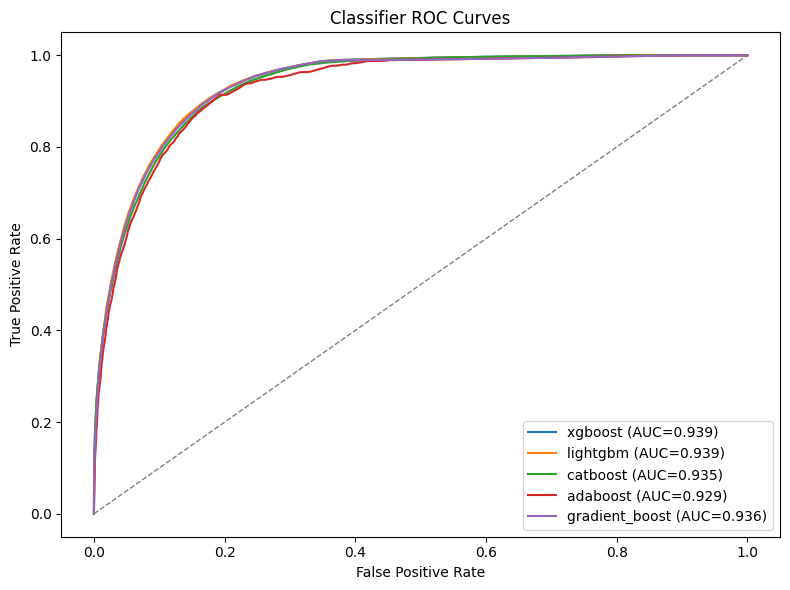

In [13]:
# Plot ROC curves for all classifiers to compare zero detection quality.
plt.figure(figsize=(8, 6))
for clf_name, preds in classifier_predictions.items():
    fpr, tpr, _ = roc_curve(y_test_zero, preds["proba"])
    plt.plot(fpr, tpr, label=f"{clf_name} (AUC={auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()


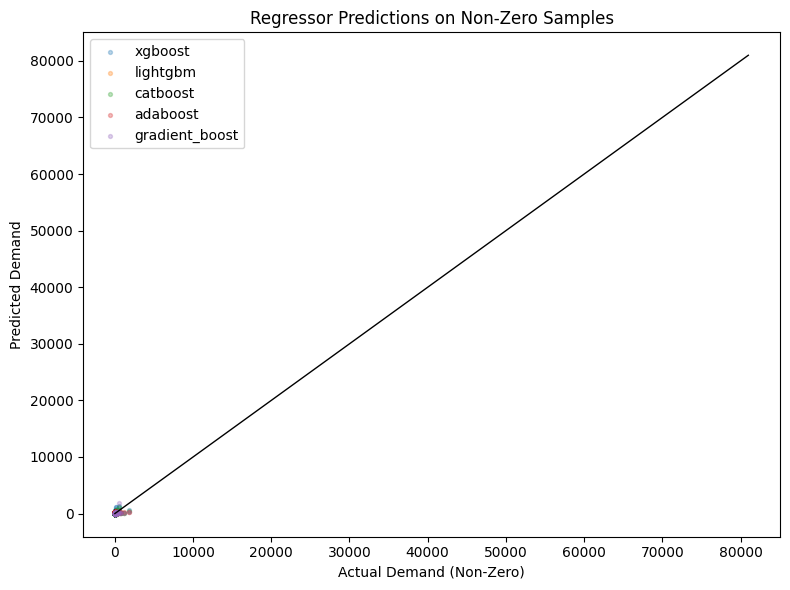

In [14]:
# Plot non-zero regression performance for each regressor.
nonzero_test_mask = y_test.values > 0
plt.figure(figsize=(8, 6))
np.random.seed(42)
sample_idx = np.random.choice(np.where(nonzero_test_mask)[0], size=min(2000, nonzero_test_mask.sum()), replace=False)
for reg_name, preds in regressor_predictions.items():
    plt.scatter(y_test.values[sample_idx], preds[sample_idx], s=8, alpha=0.3, label=reg_name)

max_val = max(y_test.values[nonzero_test_mask].max(), max(preds[nonzero_test_mask].max() for preds in regressor_predictions.values()))
plt.plot([0, max_val], [0, max_val], color="black", linewidth=1)
plt.xlabel("Actual Demand (Non-Zero)")
plt.ylabel("Predicted Demand")
plt.title("Regressor Predictions on Non-Zero Samples")
plt.legend()
plt.tight_layout()
plt.show()


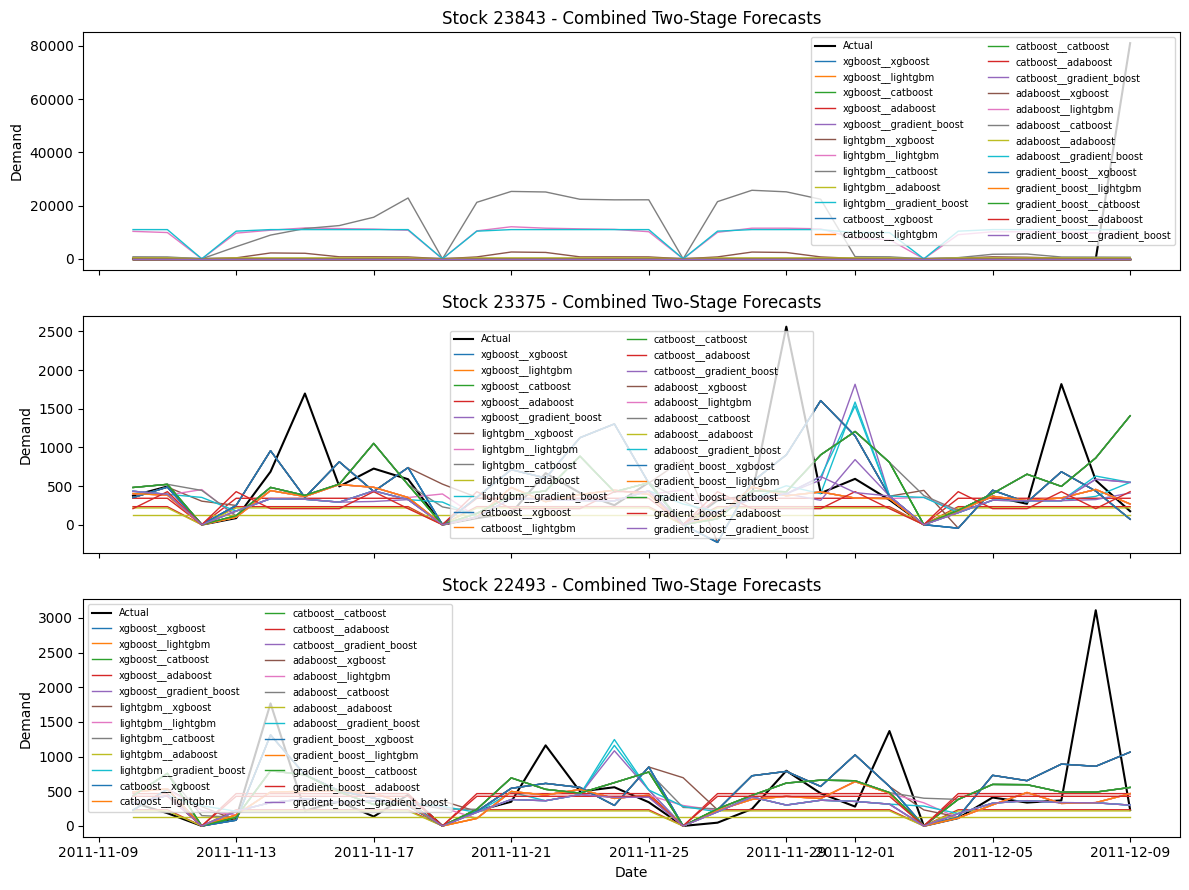

In [15]:
# Visualize combined two-stage forecasts for top-demand products.
use_cols = ["stock_code", "date", "demand_qty"]
max_date = None
for chunk in pd.read_csv(tabular_path, usecols=use_cols, chunksize=200_000, low_memory=False):
    chunk["date"] = pd.to_datetime(chunk["date"])
    chunk_max = chunk["date"].max()
    max_date = chunk_max if max_date is None else max(max_date, chunk_max)

cutoff = max_date - pd.Timedelta(days=30)
test_chunks = []
for chunk in pd.read_csv(tabular_path, usecols=use_cols, chunksize=200_000, low_memory=False):
    chunk["date"] = pd.to_datetime(chunk["date"])
    test_chunk = chunk[chunk["date"] > cutoff]
    if not test_chunk.empty:
        test_chunks.append(test_chunk)

df_test = pd.concat(test_chunks, ignore_index=True)
df_test = df_test.sort_values(["stock_code", "date"]).reset_index(drop=True)

if len(df_test) != len(y_test):
    raise ValueError("Mismatch between test rows and predictions.")

df_test["y_true"] = y_test.values

top_k = 3
top_products = (
    df_test.groupby("stock_code")["y_true"]
    .sum()
    .sort_values(ascending=False)
    .head(top_k)
    .index
)

fig, axes = plt.subplots(top_k, 1, figsize=(12, 3 * top_k), sharex=True)
if top_k == 1:
    axes = [axes]

for ax, stock_code in zip(axes, top_products):
    subset = df_test[df_test["stock_code"] == stock_code]
    ax.plot(subset["date"], subset["y_true"], label="Actual", linewidth=1.5, color="black")
    for model_name, preds in combined_predictions.items():
        ax.plot(subset["date"], preds[subset.index], label=model_name, linewidth=1)
    ax.set_title(f"Stock {stock_code} - Combined Two-Stage Forecasts")
    ax.set_ylabel("Demand")
    ax.legend(ncol=2, fontsize=7)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()
